In [2]:
#1
import requests
import pandas as pd

url = "https://api.spacexdata.com/v4/launches/past"
data = requests.get(url).json()

df = pd.json_normalize(data)
df.head()

,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,...,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'mer...",Engine failure at 33 seconds and loss of vehicle,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-fa...,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'har...",Successful first stage burn and transition to ...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-roc...,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'resi...",Residual stage 1 thrust led to collision betwe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1...,https://en.wikipedia.org/wiki/Trailblazer_(sat...,NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],Ratsat was carried to orbit on the first succe...,[],[],...,None,None,[],[],None,https://www.youtube.com/watch?v=dLQ2tZEH6G0,dLQ2tZEH6G0,https://en.wikipedia.org/wiki/Ratsat,https://en.wikipedia.org/wiki/Ratsat,NaN
4,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,True,[],None,[],[],...,None,None,[],[],http://www.spacex.com/press/2012/12/19/spacexs...,https://www.youtube.com/watch?v=yTaIDooc8Og,yTaIDooc8Og,http://www.spacex.com/news/2013/02/12/falcon-1...,https://en.wikipedia.org/wiki/RazakSAT,NaN


In [3]:
#2
# Important columns select करो
df = df[['name', 'date_utc', 'success']]

# Date format convert करो
df['date_utc'] = pd.to_datetime(df['date_utc'])

# Null values check
print(df.isnull().sum())

df.head()

name        0
date_utc    0
success     1
dtype: int64


,name,date_utc,success
0,FalconSat,2006-03-24 22:30:00+00:00,False
1,DemoSat,2007-03-21 01:10:00+00:00,False
2,Trailblazer,2008-08-03 03:34:00+00:00,False
3,RatSat,2008-09-28 23:15:00+00:00,True
4,RazakSat,2009-07-13 03:35:00+00:00,True


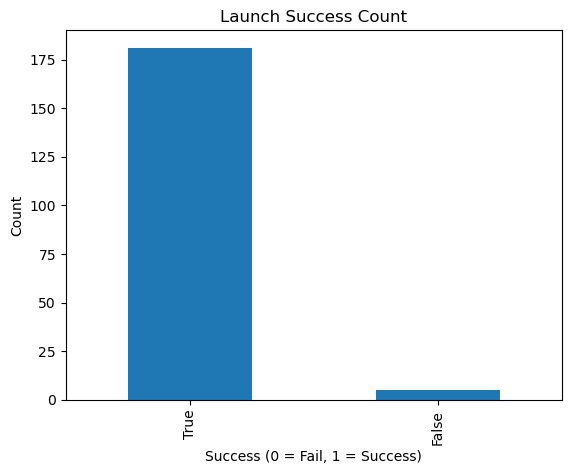

In [4]:
#3
import matplotlib.pyplot as plt

df['success'].value_counts().plot(kind='bar')
plt.title("Launch Success Count")
plt.xlabel("Success (0 = Fail, 1 = Success)")
plt.ylabel("Count")
plt.show()

In [5]:
#4
import sqlite3

conn = sqlite3.connect("spacex.db")

# Table बनाओ
df.to_sql("launches", conn, if_exists='replace', index=False)

# Query run करो
query = "SELECT success, COUNT(*) as count FROM launches GROUP BY success"
result = pd.read_sql(query, conn)

result

,success,count
0,NaN,1
1,0.0,5
2,1.0,181


In [6]:
#5
import folium

map = folium.Map(location=[28.5, -80.5], zoom_start=5)

folium.Marker([28.5, -80.5], popup="Launch Site").add_to(map)

map

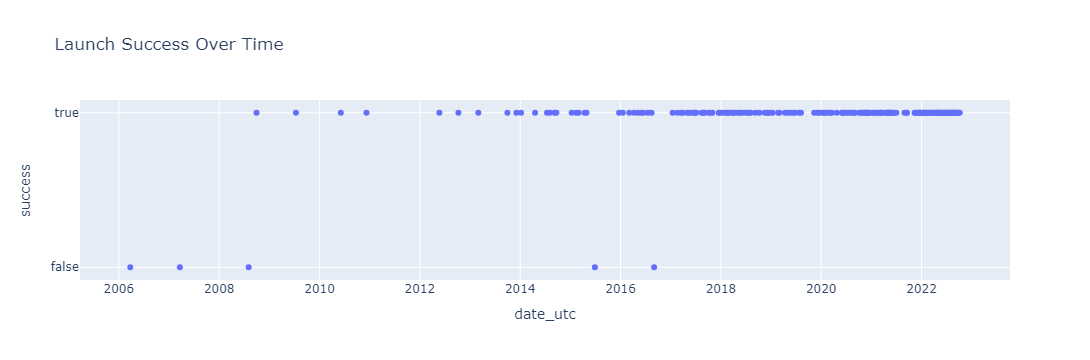

In [7]:
#6
import plotly.express as px

fig = px.scatter(df, x="date_utc", y="success", title="Launch Success Over Time")
fig.show()

In [12]:
#7
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Step 1: Missing values handle करो
df = df.dropna(subset=['success'])

# Step 2: Boolean → Integer (True=1, False=0)
df['success'] = df['success'].astype(int)

# Step 3: Feature create करो (date से)
df['year'] = df['date_utc'].dt.year

# Features और target define करो
X = df[['year']]
y = df['success']

# Step 4: Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 5: Model train करो
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 6: Accuracy check
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_6272\1700381466.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\lenovo\AppData\Local\Temp\ipykernel_6272\1700381466.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [10]:
#8
# Success rate
success_rate = df['success'].mean()
print("Success Rate:", success_rate)

Success Rate: 0.9731182795698925
